In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

from xgboost import XGBClassifier
from xgboost import plot_importance

# CARICAMENTO DATASET e PULIZIA

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Info

In [3]:
print("Shape del dataset:", df.shape)

print("\n--- Info ---")
print(df.info())

print("\n--- Descrizione ---")
print(df.describe())

print("\n--- Numero valori nulli ---")
print(df.isnull().sum())

print("\n--- Righe duplicate ---")
print(df[df.duplicated()])

Shape del dataset: (891, 12)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Descrizione ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2

## Rimuovo 'Embarked' vuoti

Nel dataset del Titanic, la colonna Embarked indica il porto di imbarco del passeggero:
- S = porto principale di partenza del Titanic - Southampton, Inghilterra (la maggior parte dei passeggeri)
- C = porto di Cherbourg, Francia (molti passeggeri di 1ª classe)
- Q = porto Queenstown (oggi Cobh), Irlanda (molti passeggeri di 3ª classe)

In [4]:
df_clean = df.dropna(subset=["Embarked"]).copy()

print("\n--- Numero valori nulli ---")
print(df_clean.isnull().sum())


--- Numero valori nulli ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


## Media per 'Age' vuoti

In [5]:
# Sto modificando un DF che deriva da un sottoinsieme di un altro -> modifico le colonne con .loc 
df_clean.loc[:, "Age"] = df["Age"].fillna(df["Age"].mean())

print("\n--- Numero valori nulli ---")
print(df_clean.isnull().sum())


--- Numero valori nulli ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


## "Not assigned" per 'Cabin' NaN

In [6]:
# Sto modificando un DF che deriva da un sottoinsieme di un altro -> modifico le colonne con .loc 
df_clean.loc[:, "Cabin"] = df["Cabin"].fillna("Not assigned")

print("\n--- Numero valori nulli ---")
print(df_clean.isnull().sum())


--- Numero valori nulli ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## Elimino sigla in 'Ticket'

Prefissi:
- A/5, A/4 -> Codici per biglietti di emigrazione a basso costo
- STON/O2. -> Biglietti venduti dalla compagnia Stonehouse per emigranti
- PC -> “Pontchartrain”  ->  agenzia di prima classe, biglietti molto costosi
- S.O./P.P. -> “State Official / Paid Passage” (passaggi pagati dallo Stato)
- C.A. -> Biglietti di Cabin Class (spesso 2ª classe superiore)
- W./C. -> White Star Line (la compagnia proprietaria del Titanic)

Numeri semplici:
- biglietti standard, spesso per terza classe

Ogni ticket identifica:
- famiglie o gruppi che hanno viaggiato insieme -> (stesso ticket  ->  stessa cabina  ->  stessa probabilità di sopravvivenza)
- categorie sociali/economiche
- classi diverse dal numero “Pclass”



In [7]:
# Estraggo il prefisso -> qualunque cosa non numerica all'inizio
df_clean.loc[:, "TicketPrefisso"] = df_clean["Ticket"].str.extract(r"^(.*\D)\d+$")

# Riempio i NaN (cioè ticket senza prefisso) con "Not assigned"
df_clean.loc[:, "TicketPrefisso"] = df_clean["TicketPrefisso"].fillna("Not assigned").str.strip()

# Estraggo solo il numero del ticket
df_clean.loc[:, "TicketNum"] = df_clean["Ticket"].str.extract(r"(\d+)$")

df_clean.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketPrefisso,TicketNum
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Not assigned,S,A/5,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,PC,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Not assigned,S,STON/O2.,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Not assigned,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Not assigned,S,Not assigned,373450


## Nuove Info

In [8]:
print("Shape del dataset:", df_clean.shape)

print("\n--- Info ---")
print(df_clean.info())

Shape del dataset: (889, 14)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     889 non-null    int64  
 1   Survived        889 non-null    int64  
 2   Pclass          889 non-null    int64  
 3   Name            889 non-null    object 
 4   Sex             889 non-null    object 
 5   Age             889 non-null    float64
 6   SibSp           889 non-null    int64  
 7   Parch           889 non-null    int64  
 8   Ticket          889 non-null    object 
 9   Fare            889 non-null    float64
 10  Cabin           889 non-null    object 
 11  Embarked        889 non-null    object 
 12  TicketPrefisso  889 non-null    object 
 13  TicketNum       885 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 104.2+ KB
None


## Rimuovo 'TicketNum' vuoti

In [9]:
df_new = df_clean.dropna(subset=["TicketNum"]).copy()
df_new["TicketNum"] = df_new["TicketNum"].astype(float)

print("\n--- Numero valori nulli ---")
print(df_new.isnull().sum())


--- Numero valori nulli ---
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin             0
Embarked          0
TicketPrefisso    0
TicketNum         0
dtype: int64


## Vedo se vanno in famiglia o sono soli, e il titolo che hanno

In [10]:
df_new["FamilySize"] = df_new["SibSp"] + df_new["Parch"] + 1
df_new["IsAlone"] = (df_new["FamilySize"] == 1).astype(int)

df_new["Title"] = df_new["Name"].str.extract(r',\s([^.]).')
rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
df_new["Title"] = df_new["Title"].replace(rare_titles, "Rare")

df_new.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketPrefisso,TicketNum,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Not assigned,S,A/5,21171.0,2,0,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,PC,17599.0,2,0,M
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Not assigned,S,STON/O2.,3101282.0,1,1,M
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Not assigned,113803.0,2,0,M
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Not assigned,S,Not assigned,373450.0,1,1,M


## Estraggo il ponte delle cabine

In [11]:
df_new["Deck"] = df_new["Cabin"].astype(str).str[0]
df_new.loc[df_new["Deck"] == "N", "Deck"] = "Unknown"

df_new.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketPrefisso,TicketNum,FamilySize,IsAlone,Title,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Not assigned,S,A/5,21171.0,2,0,M,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,PC,17599.0,2,0,M,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Not assigned,S,STON/O2.,3101282.0,1,1,M,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Not assigned,113803.0,2,0,M,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Not assigned,S,Not assigned,373450.0,1,1,M,Unknown


## Elimino le colonne che ho usato per creare quelle nuove

In [12]:
df_model = df_new.drop(columns=["PassengerId", "Name", "Cabin", "Ticket"])

print(df_model.shape)
df_model.head()

(885, 14)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TicketPrefisso,TicketNum,FamilySize,IsAlone,Title,Deck
0,0,3,male,22.0,1,0,7.2500,S,A/5,21171.0,2,0,M,Unknown
1,1,1,female,38.0,1,0,71.2833,C,PC,17599.0,2,0,M,C
2,1,3,female,26.0,0,0,7.9250,S,STON/O2.,3101282.0,1,1,M,Unknown
3,1,1,female,35.0,1,0,53.1000,S,Not assigned,113803.0,2,0,M,C
4,0,3,male,35.0,0,0,8.0500,S,Not assigned,373450.0,1,1,M,Unknown


## Dummies

In [13]:
df_model = pd.get_dummies(df_model, columns=["Sex", "Embarked", "TicketPrefisso", "Title", "Deck"], drop_first=True)

print(df_model.shape)
df_model.head()

(885, 70)


,Survived,Pclass,Age,SibSp,Parch,Fare,TicketNum,FamilySize,IsAlone,Sex_male,...,Title_S,Title_t,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,22.0,1,0,7.2500,21171.0,2,0,True,...,False,False,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,17599.0,2,0,False,...,False,False,False,True,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,3101282.0,1,1,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,113803.0,2,0,False,...,False,False,False,True,False,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,373450.0,1,1,True,...,False,False,False,False,False,False,False,False,False,True


# ========= DEEP LEARNING =========

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## --- 1. PREPARAZIONE DATI ---

In [15]:
# Carichiamo il dataset
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

# Split Train/Test (Fondamentale per valutare l'overfitting)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

# !!! PASSAGGIO CRUCIALE !!!
# A differenza dei Decision Tree, le Reti Neurali richiedono input scalati.
# Se non lo fate, i gradienti esploderanno o il training sarà lentissimo.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print(f"Shape Input: {X_train.shape[1]} features") # Dovrebbe essere 8

Shape Input: 69 features


## --- 2. COSTRUZIONE MODELLO (Architecture Design) ---

In [16]:
model_reg = models.Sequential([
    # Input Layer implicito nella definizione del primo Dense
    # Struttura a "Imbuto": Partiamo larghi e stringiamo
    layers.Dense(32, activation="relu", input_shape=X_train.shape[1:]),
    
    # Secondo strato hidden per catturare non-linearità complesse
    layers.Dense(16, activation="relu"),
    
    # OUTPUT LAYER (Regressione)
    # 1 solo neurone (prezzo). 
    # Nessuna attivazione (può essere qualsiasi valore positivo).
    layers.Dense(1) 
])

/Users/ashura/Documents/GitHub/Anzellotti_DepositoCorso/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## --- 3. COMPILAZIONE (Il cervello) ---

In [17]:
model_reg.compile(
    loss="mse",                # Mean Squared Error: standard per regressione
    optimizer="adam",          # Adam gestisce il learning rate da solo
    metrics=["mae"]            # Monitoriamo l'errore assoluto (più leggibile dell'MSE)
)

## --- 4. TRAINING (Il sudore) ---

In [18]:
history = model_reg.fit(
    X_train, y_train,
    epochs=20,                 # Proviamo 20 giri completi
    batch_size=32,             # Aggiorniamo i pesi ogni 32 case
    validation_data=(X_valid, y_valid), # Controllo in tempo reale
    verbose=1
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0647 - mae: 0.6905 - val_loss: 0.6083 - val_mae: 0.5717
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5306 - mae: 0.5081 - val_loss: 0.4247 - val_mae: 0.5083
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3403 - mae: 0.4233 - val_loss: 0.3249 - val_mae: 0.4572
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2544 - mae: 0.3718 - val_loss: 0.2702 - val_mae: 0.4222
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2106 - mae: 0.3384 - val_loss: 0.2352 - val_mae: 0.3921
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1797 - mae: 0.3120 - val_loss: 0.2135 - val_mae: 0.3714
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1596 - mae: 0.2954 - val_loss: 0.2008 - val_mae: 0.3622
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1469 - mae: 0.2878 - val_loss: 0.1932 - val_mae: 0.3579
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1368 - mae: 

## --- 5. ANALISI DEI RISULTATI ---

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1993 - mae: 0.3341

Errore Medio Assoluto sul Test Set: 0.33 (in centinaia di migliaia di $)


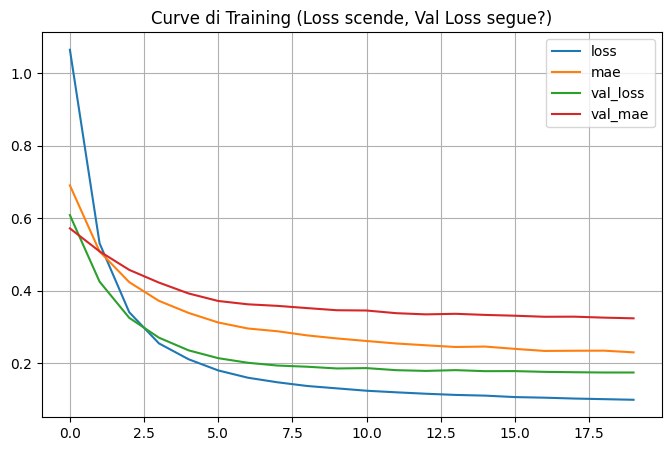

In [19]:
# Valutazione finale sul Test Set (dati mai visti)
mse_test, mae_test = model_reg.evaluate(X_test, y_test)
print(f"\nErrore Medio Assoluto sul Test Set: {mae_test:.2f} (in centinaia di migliaia di $)")

# Visualizzazione della curva di apprendimento
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Curve di Training (Loss scende, Val Loss segue?)")
plt.show()